In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from jax import vmap, lax

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

from hmfc.model import HierarchicalBernoulliLDS
from hmfc.gibbs import gibbs_step


## Simulate from the model

In [ ]:
# Sample dataset
key = jr.PRNGKey(0)

num_subjects = 3
num_trials = 10
num_iters = 10000
num_inputs = 2

true_mu_a = 0.98
true_sigma_a = 0.025
true_mu_w = jnp.array([0.0, 0.2])
true_sigma_w = jnp.array([1.0, 1.0])
true_mu_sigmasq = 0.1**2
true_beta_sigmasq = 0.1**2
true_sigma_mu_x = 0.25

# Create our true model
true_model = HierarchicalBernoulliLDS(num_inputs,
                                      mu_a=true_mu_a, 
                                      sigma_a=true_sigma_a, 
                                      mu_w=true_mu_w, 
                                      sigma_w=true_sigma_w, 
                                      mu_sigmasq=true_mu_sigmasq,
                                      beta_sigmasq=true_beta_sigmasq, 
                                      sigma_mu_x=true_sigma_mu_x)

# Sample inputs
inputs = tfd.Normal(0, 1).sample(sample_shape=(num_subjects, num_trials, num_inputs), seed=key)

# REQUIRE THAT INPUTS ARE MEAN ZERO
inputs -= inputs.mean(axis=0)

# Sample true params, states, and emissions
true_params, true_states, emissions = true_model.sample(key, inputs)
masks = jnp.ones_like(emissions)

## Initialize a new model for fitting the data

In [18]:

# Initialize model
init_mu_a = 0.90
init_sigma_a = 0.1
init_mu_w = jnp.zeros(num_inputs)
init_sigma_w = jnp.repeat(1.0, num_inputs)
init_mu_sigmasq = 0.1**2
init_beta_sigmasq = 0.1**2
init_sigma_mu_x = true_sigma_mu_x

# Create our true model
model = HierarchicalBernoulliLDS(num_inputs,
                                 mu_a=init_mu_a, 
                                 sigma_a=init_sigma_a, 
                                 mu_w=init_mu_w, 
                                 sigma_w=init_sigma_w, 
                                 mu_sigmasq=init_mu_sigmasq,
                                 beta_sigmasq=init_beta_sigmasq, 
                                 sigma_mu_x=init_sigma_mu_x)

params, states, _ = model.sample(key, inputs)

## Run the Geweke Test

In [19]:
def geweke_step(carry, key):
    model, params, emissions, states = carry
    
    # Perform one Gibbs step
    this_key, key = jr.split(key)
    lp, states, params, model = gibbs_step(this_key, emissions, masks, states, inputs, params, model,
                                           update_global_weights=False,
                                           update_global_ar=False,
                                           update_global_ar_var=False)

    # Sample new emissions for the Geweke step
    def _sample_emissions(key, params, states, inputs):
        return tfd.Bernoulli(states + inputs @ params['w']).sample(seed=key)
    emissions = vmap(_sample_emissions)(jr.split(key, num_subjects), params, states, inputs)

    # Extract outputs
    output = (lp, model, params, emissions, states)
    new_carry = (model, params, emissions, states)
    return new_carry, output


init_carry = (model, params, emissions, states)
_, samples = lax.scan(geweke_step, init_carry, jr.split(key, num_iters))
(lps, model_samples, params_samples, emissions_samples, states_samples) = samples
jax.block_until_ready(lps)

Array([ 36.751873,  58.53463 ,  46.150917, ..., -16.592278, -19.292168,
       -29.83341 ], dtype=float32)

## Compare samples to the prior

Text(0, 0.5, 'log joint probability')

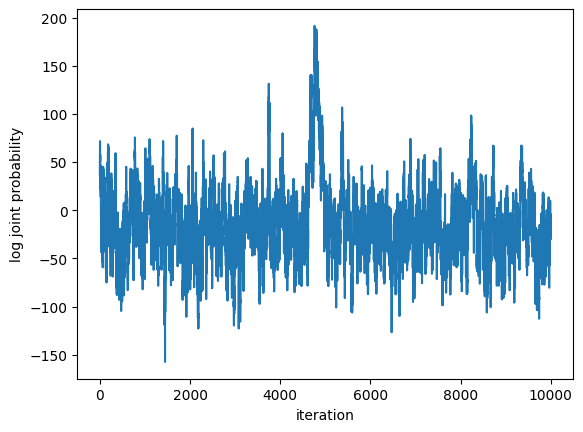

In [20]:
plt.plot(lps)
plt.xlabel("iteration")
plt.ylabel("log joint probability")

In [8]:
model_samples

HierarchicalBernoulliLDS(
  log_lambda_mu=weak_f32[10000],
  log_lambda_beta=weak_f32[10000],
  mu_w=f32[10000,2],
  log_sigma_w=weak_f32[10000,2],
  logit_mu_a=weak_f32[10000],
  log_sigma_a=weak_f32[10000],
  log_sigma_mu_x=weak_f32[10000],
  log_mu_sigmasq=f32[10000],
  log_beta_sigmasq=f32[10000]
)

### Check log $\mu_{\sigma^2}$

Text(0, 0.5, '$p(\\log \\mu)$')

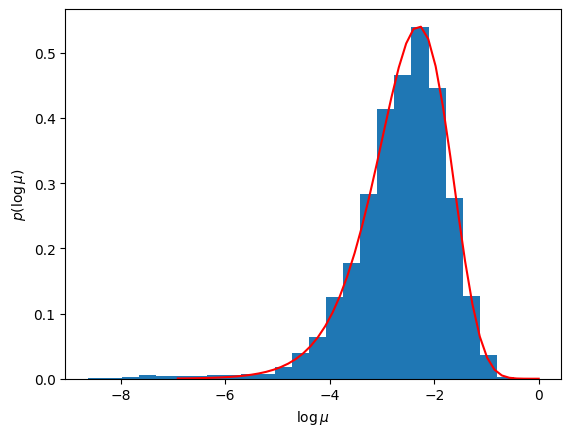

In [21]:
log_mu_vals = jnp.linspace(jnp.log(0.001), jnp.log(1.0))
p_log_mu = tfd.TransformedDistribution(
            tfd.Gamma(2.0, 2.0 * model.lambda_mu),
            tfp.bijectors.Log(),
        )
plt.hist(model_samples.log_mu_sigmasq.ravel(), 25, density=True)
plt.plot(log_mu_vals, jnp.exp(p_log_mu.log_prob(log_mu_vals)), '-r')
plt.xlabel(r"$\log \mu$")
plt.ylabel(r"$p(\log \mu)$")

### Check $\log \beta$

Text(0, 0.5, '$p(\\log \\beta)$')

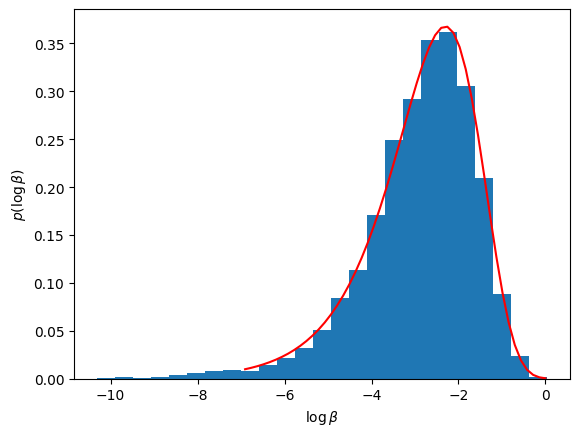

In [22]:
log_beta_vals = jnp.linspace(jnp.log(0.001), jnp.log(1.0))
p_log_beta = tfd.TransformedDistribution(
            tfd.Exponential(model.lambda_beta),
            tfp.bijectors.Log(),
        )
plt.hist(model_samples.log_beta_sigmasq.ravel(), 25, density=True)
plt.plot(log_beta_vals, jnp.exp(p_log_beta.log_prob(log_beta_vals)), '-r')
plt.xlabel(r"$\log \beta$")
plt.ylabel(r"$p(\log \beta)$")

### Check per-subject weights

Since $mu_w = 0$ and $sigma_w = 1$, the per subject weights are distributed as, $w_i \sim \mathrm{N}(0,1)$. 

Text(0, 0.5, '$p(w)$')

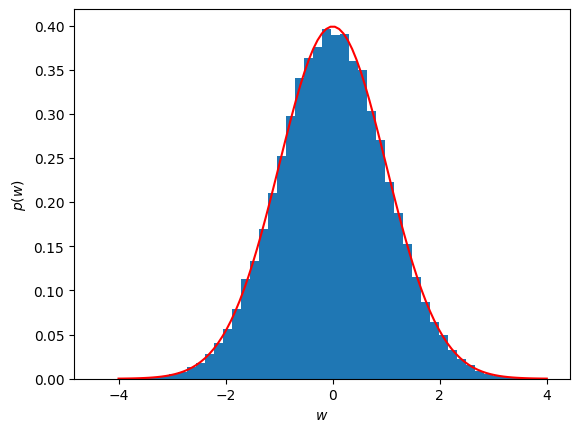

In [23]:
p_w = tfd.Normal(0, 1)
w_vals = jnp.linspace(-4, 4, 100)

plt.hist(params_samples['w'].ravel(), 50, density=True)
plt.plot(w_vals, jnp.exp(p_w.log_prob(w_vals)), '-r')
plt.xlabel(r"$w$")
plt.ylabel(r"$p(w)$")

### Check per-subject dynamics coefficient

Under the prior,
\begin{align*}
a_i &\sim \mathrm{TruncNorm}(mu_a, \sigma_a^2; [0, a_{\mathsf{max}}])
\end{align*}

Text(0, 0.5, '$p(a)$')

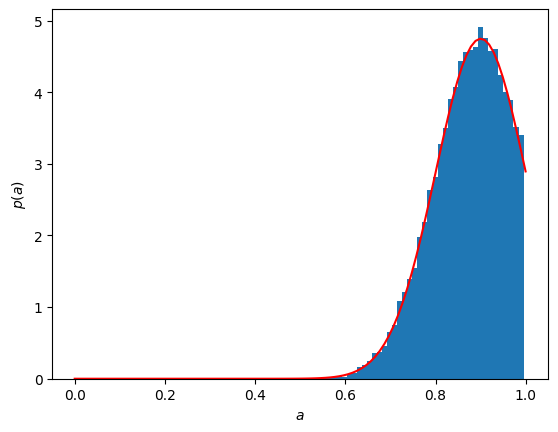

In [24]:
from jax.nn import sigmoid
#from hmfc.constants import A_MAX

p_a = tfd.TruncatedNormal(sigmoid(model.logit_mu_a), jnp.exp(model.log_sigma_a), 0.0, A_MAX)
a_vals = jnp.linspace(0, A_MAX, 100)

plt.hist(params_samples['a'].ravel(), 50, density=True)
plt.plot(a_vals, jnp.exp(p_a.log_prob(a_vals)), '-r')
plt.xlabel(r"$a$")
plt.ylabel(r"$p(a)$")

### Check per-subject bias


Text(0, 0.5, '$p(\\mu_0)$')

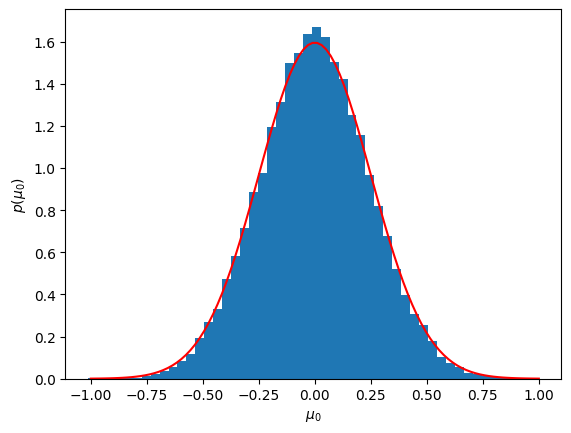

In [25]:
p_mu_x = tfd.Normal(0.0, jnp.exp(model.log_sigma_mu_x))
mu_x_vals = jnp.linspace(-1, 1, 100)

plt.hist(params_samples['mu_x'].ravel(), 50, density=True)
plt.plot(mu_x_vals, jnp.exp(p_mu_x.log_prob(mu_x_vals)), '-r')
plt.xlabel(r"$\mu_0$")
plt.ylabel(r"$p(\mu_0)$")

### Check per-subject dynamics variance

Text(0, 0.5, '$p(\\sigma^2)$')

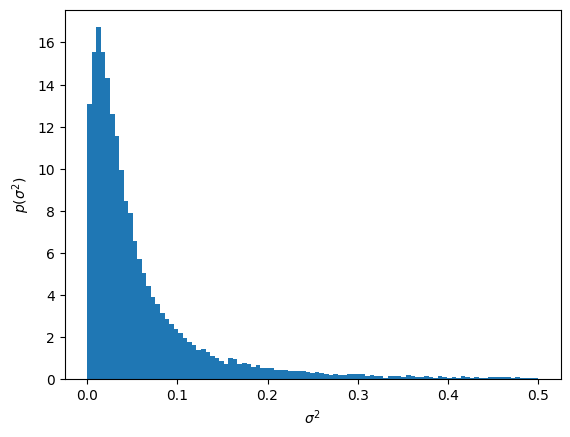

In [26]:
# p_sigmasq = tfd.InverseGamma(jnp.exp(model.log_alpha), jnp.exp(model.log_beta))
sigmasq_values = jnp.linspace(0, 0.5, 100)

plt.hist(params_samples['sigmasq'].ravel(), sigmasq_values, density=True)
# plt.plot(sigmasq_values, jnp.exp(p_sigmasq.log_prob(sigmasq_values)), '-r')
plt.xlabel(r"$\sigma^2$")
plt.ylabel(r"$p(\sigma^2)$")
# plt.xlim(0,1)